# Adversarial Transferability Framework: Demo
This notebook demonstrates **Gradient-based Adversarial Evasion Attacks** and evaluates their **Transferability** from a surrogate model to a target model on the Tiny ImageNet-200 dataset.

In [1]:
import torch
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Ensure the project root is in sys.path for imports
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

from utils.dataset_utils import get_dataloaders, get_inverse_transform, download_tiny_imagenet
from models.example_models import get_resnet18, get_efficientnet_v2_s
from utils.training_utils import train_model, load_model_weights
from attacks.evasion_attacks import evaluate_transferability, fgsm_attack, pgd_attack

device = 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else \
             'cuda' if torch.cuda.is_available() else \
             'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: xpu


## 1. Setup Data and Models

In [5]:
download_tiny_imagenet('./data')
target_loader, surrogate_loader, val_loader = get_dataloaders('./data/tiny-imagenet-200', batch_size=64)

target_model = get_efficientnet_v2_s(pretrained=True)
surrogate_model = get_resnet18(pretrained=True)
train_type="labels"  # Options: "clean", "labels", "logits"

n_epochs = 5

# Load or train target model (Standard training)
if not load_model_weights(target_model, "clean", device=device):
    print("\nTraining Target Model...")
    train_model(
        target_model,
        target_loader,
        val_loader,
        epochs=n_epochs,
        device=device,
        show_tqdm_bar=True,
    )
else:
    print(f"\nLoaded Target Model: {target_model.name}")

# Load or train surrogate model (using teacher labels from target)
if not load_model_weights(surrogate_model, "labels", device=device, target_model=target_model):
    print("\nTraining Surrogate Model with Teacher Labels...")
    train_model(
        surrogate_model, surrogate_loader, val_loader, 
        epochs=n_epochs, device=device, 
        teacher=target_model,
        show_tqdm_bar=True,
    )
else:
    print(f"\nLoaded Surrogate Model: {surrogate_model.name} trained with {train_type} from {target_model.name}")

target_model.eval().to(device)
surrogate_model.eval().to(device)
print("Models ready.")

Tiny ImageNet-200 already present.

Loaded Target Model: efficientnet_v2_s_pretrained

Loaded Surrogate Model: resnet18_pretrained trained with labels from efficientnet_v2_s_pretrained
Models ready.


## 2. Evaluate Transferability across Epsilon Budgets

Testing epsilon: 0.0...
Testing epsilon: 0.01...
Testing epsilon: 0.03...
Testing epsilon: 0.05...
Testing epsilon: 0.1...


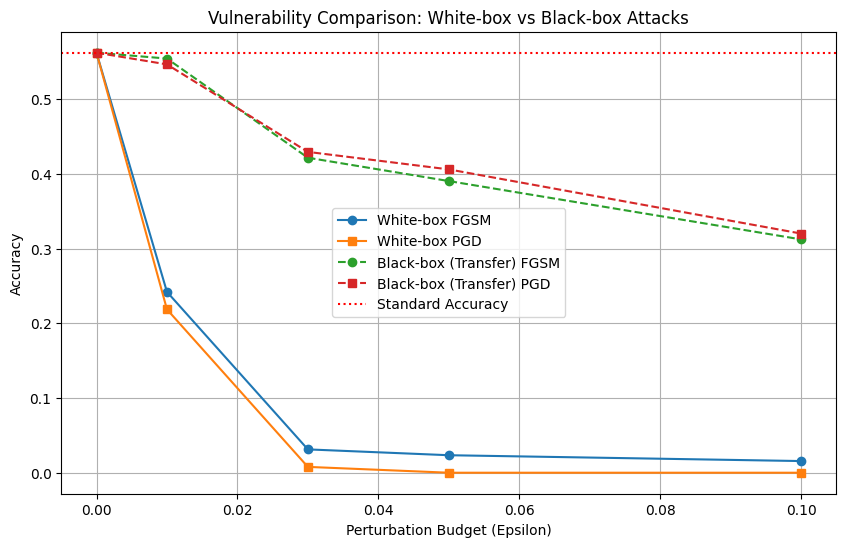

In [6]:
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]
wb_results = []
bb_results = []

for eps in epsilons:
    print(f"Testing epsilon: {eps}...")
    clean, wb_fgsm, wb_pgd = evaluate_transferability(target_model, target_model, val_loader, epsilon=eps, device=device, limit=128)
    clean, bb_fgsm, bb_pgd = evaluate_transferability(surrogate_model, target_model, val_loader, epsilon=eps, device=device, limit=128)
    
    wb_results.append((wb_fgsm, wb_pgd))
    bb_results.append((bb_fgsm, bb_pgd))

wb_fgsm_res, wb_pgd_res = zip(*wb_results)
bb_fgsm_res, bb_pgd_res = zip(*bb_results)

plt.figure(figsize=(10, 6))
plt.plot(epsilons, wb_fgsm_res, 'o-', label='White-box FGSM')
plt.plot(epsilons, wb_pgd_res, 's-', label='White-box PGD')
plt.plot(epsilons, bb_fgsm_res, 'o--', label='Black-box (Transfer) FGSM')
plt.plot(epsilons, bb_pgd_res, 's--', label='Black-box (Transfer) PGD')
plt.axhline(y=clean, color='r', linestyle=':', label='Standard Accuracy')

plt.xlabel('Perturbation Budget (Epsilon)')
plt.ylabel('Accuracy')
plt.title('Vulnerability Comparison: White-box vs Black-box Attacks')
plt.legend()
plt.grid(True)
plt.show()

## 3. Visualize Adversarial Examples

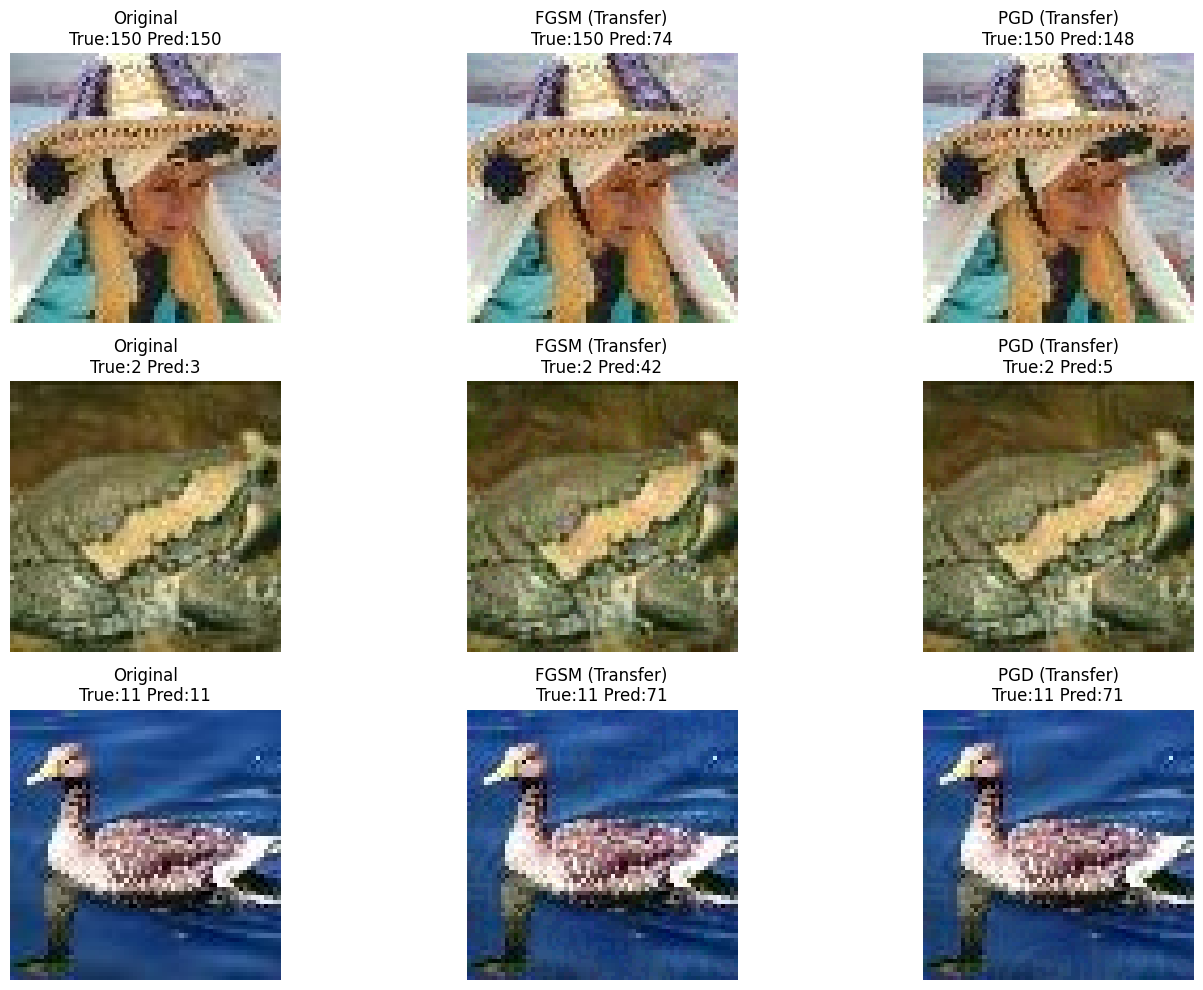

In [7]:
images, labels = next(iter(val_loader))
images, labels = images[3:6].to(device), labels[3:6].to(device)
eps = 0.1

# Generate gradients from surrogate
images.requires_grad = True
outputs_surr = surrogate_model(images)
loss = torch.nn.CrossEntropyLoss()(outputs_surr, labels)
surrogate_model.zero_grad()
loss.backward()

adv_fgsm = fgsm_attack(images, eps, images.grad)
adv_pgd = pgd_attack(surrogate_model, images, labels, epsilon=eps, alpha=eps/4, iters=10, device=device)
# Predictions from target model
with torch.no_grad():
    clean_preds = target_model(images).argmax(1)
    fgsm_preds = target_model(adv_fgsm).argmax(1)
    pgd_preds = target_model(adv_pgd).argmax(1)

inv_trans = get_inverse_transform()

plt.figure(figsize=(15, 10))
for i in range(3):
    for j, (img, title, pred) in enumerate([
        (images[i], "Original", clean_preds[i]),
        (adv_fgsm[i], "FGSM (Transfer)", fgsm_preds[i]),
        (adv_pgd[i], "PGD (Transfer)", pgd_preds[i])
    ]):
        plt.subplot(3, 3, i*3 + j + 1)
        img_vis = inv_trans(img.clone().detach().cpu()).permute(1, 2, 0).numpy()
        plt.imshow(np.clip(img_vis, 0, 1))
        plt.title(f"{title}\nTrue:{labels[i].item()} Pred:{pred.item()}")
        plt.axis('off')
plt.tight_layout()
plt.show()